# Clean data and process

In [8]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== User settings =====
base_dir = Path(r"D:\Arduino\Physic2 project\Data processing\Data Session use!!!!")   # change if needed
min_runtime_s = 29.0                                    # keep only runs >= this
exclude_transient_s_start = 3.0                         # remove first few seconds in averaging
exclude_transient_s_end = 2.0                           # remove last few seconds in averaging
use_absolute_thrust = True                              # compare thrust magnitude

# Optional manual order for nicer plots
condition_order = ["Without dome", "With dome gina", "With dome Saipan"]

condition_colors = {
    "Without dome": "blue",
    "With dome gina": "orange",
    "With dome Saipan": "green",
}


In [9]:
def parse_ts(line):
    m = re.match(r"\[(.*?)\]", line)
    return pd.to_datetime(m.group(1), errors="coerce") if m else pd.NaT


def parse_serial_log(path):
    rows = []
    with open(path, encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()
            ts = parse_ts(line)
            event = None
            value = np.nan

            if "[TX]" in line:
                if "CAL=" in line:
                    event = "CAL"
                    m = re.search(r"CAL=([0-9.]+)", line)
                    value = float(m.group(1)) if m else np.nan
                elif re.search(r"\[TX\]\s*TARE\b", line):
                    event = "TARE"
                elif re.search(r"\[TX\]\s*SPEED\s+(\d+)\b", line):
                    event = "SPEED"
                    m = re.search(r"\[TX\]\s*SPEED\s+(\d+)\b", line)
                    value = int(m.group(1)) if m else np.nan
                elif re.search(r"\[TX\]\s*ON\b", line):
                    event = "ON"
                elif re.search(r"\[TX\]\s*OFF\b", line):
                    event = "OFF"

            if "Motor disabled due to command timeout." in line:
                event = "TIMEOUT"

            rows.append({
                "ts": ts,
                "line": line,
                "event": event,
                "value": value,
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["ts", "line"], na_position="last").reset_index(drop=True)
    return df


def parse_plot_csv(path):
    df = pd.read_csv(path)
    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")

    for col in ["ms", "time_s", "current_a", "thrust_g"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "thrust_g" in df.columns:
        df["thrust_abs_g"] = df["thrust_g"].abs()
    else:
        df["thrust_g"] = np.nan
        df["thrust_abs_g"] = np.nan

    df = df.dropna(subset=["pc_time"]).sort_values("pc_time").reset_index(drop=True)
    return df


def latest_cal_time(log_df):
    cal = log_df[log_df["event"] == "CAL"]
    return cal["ts"].max() if len(cal) else pd.NaT


def weighted_mean(values, weights):
    values = pd.to_numeric(pd.Series(values).reset_index(drop=True), errors="coerce")
    weights = pd.to_numeric(pd.Series(weights).reset_index(drop=True), errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return np.nan
    return np.average(values[mask], weights=weights[mask])


In [10]:
def build_control_sessions(log_df, csv_end_ts, analysis_start_ts):
    """
    Build one control session per ON ... TIMEOUT / OFF / CSV_END window.
    The interest window is the FIRST SPEED command after ON until the end event.
    """
    events = (
        log_df[
            (log_df["ts"] >= analysis_start_ts)
            & (log_df["event"].isin(["ON", "SPEED", "TIMEOUT", "OFF"]))
        ]
        .sort_values("ts")
        .reset_index(drop=True)
    )

    segments = []
    control_session_id = 0

    on_indices = events.index[events["event"] == "ON"].tolist()

    for pos, on_idx in enumerate(on_indices):
        on_row = events.loc[on_idx]

        # Limit search to the current ON window so later ON events do not create overlaps.
        next_on_idx = on_indices[pos + 1] if pos + 1 < len(on_indices) else None
        stop_idx = (next_on_idx - 1) if next_on_idx is not None else events.index.max()
        after_on = events.loc[on_idx + 1 : stop_idx].copy()

        # Prefer TIMEOUT as the end marker.
        timeout_rows = after_on[after_on["event"] == "TIMEOUT"]
        off_rows = after_on[after_on["event"] == "OFF"]

        if len(timeout_rows):
            end_ts = timeout_rows["ts"].iloc[0]
            end_event = "TIMEOUT"
        elif len(off_rows):
            end_ts = off_rows["ts"].iloc[0]
            end_event = "OFF"
        else:
            end_ts = csv_end_ts
            end_event = "CSV_END"

        speed_rows = after_on[
            (after_on["event"] == "SPEED") &
            (after_on["ts"] < end_ts)
        ].copy()

        # Skip ON windows that never received a SPEED command.
        if speed_rows.empty:
            continue

        first_speed_row = speed_rows.iloc[0]
        start_ts = first_speed_row["ts"]
        speed_pct = int(first_speed_row["value"]) if pd.notna(first_speed_row["value"]) else np.nan
        runtime_s = (end_ts - start_ts).total_seconds() if pd.notna(end_ts) and pd.notna(start_ts) else np.nan

        if pd.notna(runtime_s) and runtime_s < 0:
            continue

        control_session_id += 1
        segments.append({
            "control_session_id": control_session_id,
            "start_event": "SPEED",
            "end_event": end_event,
            "on_ts": on_row["ts"],
            "start_ts": start_ts,
            "end_ts": end_ts,
            "runtime_s": runtime_s,
            "speed_pct": speed_pct,
            "all_speed_commands_after_on": ", ".join(
                map(str, speed_rows["value"].dropna().astype(int).tolist())
            ),
            "speed_command_count_after_on": int(len(speed_rows)),
            "qualifies": bool(pd.notna(runtime_s) and runtime_s >= min_runtime_s),
        })

    return pd.DataFrame(segments)


In [11]:
def summarize_segment(segment_df, speed_pct, runtime_s, run_id):
    rel_s = (segment_df["pc_time"] - segment_df["pc_time"].iloc[0]).dt.total_seconds()

    stable = segment_df[rel_s >= exclude_transient_s_start].copy()
    if not stable.empty:
        until_end = (segment_df["pc_time"].iloc[-1] - stable["pc_time"]).dt.total_seconds()
        stable = stable[until_end >= exclude_transient_s_end].copy()

    used = stable if len(stable) >= 10 else segment_df.copy()

    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    current = used["current_a"].dropna()
    thrust = used[thrust_col].dropna()

    current_mean = current.mean() if len(current) else np.nan
    thrust_mean = thrust.mean() if len(thrust) else np.nan

    return {
        "run_id": int(run_id),
        "speed_pct": int(speed_pct) if pd.notna(speed_pct) else np.nan,
        "runtime_s": float(runtime_s) if pd.notna(runtime_s) else np.nan,
        "samples_total": int(len(segment_df)),
        "samples_used": int(len(used)),
        "current_mean_A": current_mean,
        "current_std_A": current.std() if len(current) else np.nan,
        "current_min_A": current.min() if len(current) else np.nan,
        "current_max_A": current.max() if len(current) else np.nan,
        "thrust_mean_g": thrust_mean,
        "thrust_std_g": thrust.std() if len(thrust) else np.nan,
        "thrust_peak_g": thrust.max() if len(thrust) else np.nan,
        "efficiency_g_per_A": (
            thrust_mean / current_mean
            if pd.notna(thrust_mean) and pd.notna(current_mean) and current_mean != 0
            else np.nan
        ),
    }


In [23]:
def analyze_dataset(base_dir):
    base_dir = Path(base_dir)
    if not base_dir.exists():
        raise FileNotFoundError(f"base_dir not found: {base_dir}")

    overall_rows = []
    all_control_session_tables = []
    speed_tables = []
    raw_interest = {}

    def half_range(series):
        s = pd.to_numeric(series, errors="coerce").dropna()
        if s.empty:
            return np.nan
        return (s.max() - s.min()) / 2

    def nonzero_half_range_with_fallback(primary_series, *fallback_series):
        """
        Try max-min/2 on primary series first.
        If that gives 0 or NaN, try fallback series in order.
        If still nothing useful, return NaN instead of forcing 0.
        """
        candidates = (primary_series,) + fallback_series
        for ser in candidates:
            val = half_range(ser)
            if pd.notna(val) and val > 0:
                return val

        # if all valid candidates are exactly 0, keep NaN rather than 0
        for ser in candidates:
            val = half_range(ser)
            if pd.notna(val):
                return np.nan

        return np.nan

    folders = [p for p in base_dir.iterdir() if p.is_dir()]
    folders = sorted(
        folders,
        key=lambda p: condition_order.index(p.name) if p.name in condition_order else 999
    )

    for folder in folders:
        condition = folder.name
        log_path = folder / "serial_log.txt"
        csv_path = folder / "plot_data.csv"

        if not log_path.exists() or not csv_path.exists():
            print(f"Skipping {condition}: missing serial_log.txt or plot_data.csv")
            continue

        log_df = parse_serial_log(log_path)
        data_df = parse_plot_csv(csv_path)

        if data_df.empty:
            print(f"Skipping {condition}: plot_data.csv contains no valid pc_time rows")
            continue

        cal_ts = latest_cal_time(log_df)
        analysis_start_ts = cal_ts if pd.notna(cal_ts) else data_df["pc_time"].min()

        segs = build_control_sessions(
            log_df=log_df,
            csv_end_ts=data_df["pc_time"].max(),
            analysis_start_ts=analysis_start_ts,
        )

        frames = []
        session_rows = []

        if len(segs):
            segs = segs.copy()
            segs.insert(0, "condition", condition)

        for i, seg in segs.reset_index(drop=True).iterrows():
            sub = data_df[
                (data_df["pc_time"] >= seg["start_ts"]) &
                (data_df["pc_time"] < seg["end_ts"])
            ].copy()

            if sub.empty:
                continue

            sub["condition"] = condition
            sub["control_session_id"] = seg["control_session_id"]
            sub["speed_pct"] = seg["speed_pct"]
            sub["on_ts"] = seg["on_ts"]
            sub["segment_start_ts"] = seg["start_ts"]
            sub["segment_end_ts"] = seg["end_ts"]
            sub["segment_runtime_s"] = seg["runtime_s"]
            sub["qualifies"] = seg["qualifies"]
            sub["elapsed_from_interest_start_s"] = (
                sub["pc_time"] - seg["start_ts"]
            ).dt.total_seconds()

            frames.append(sub)

            row = summarize_segment(
                segment_df=sub,
                speed_pct=seg["speed_pct"],
                runtime_s=seg["runtime_s"],
                run_id=i + 1,
            )
            row["condition"] = condition
            row["control_session_id"] = seg["control_session_id"]
            row["on_ts"] = seg["on_ts"]
            row["start_ts"] = seg["start_ts"]
            row["end_ts"] = seg["end_ts"]
            row["end_event"] = seg["end_event"]
            row["all_speed_commands_after_on"] = seg["all_speed_commands_after_on"]
            row["speed_command_count_after_on"] = seg["speed_command_count_after_on"]
            row["qualifies"] = seg["qualifies"]

            session_rows.append(row)

        sessions_df = pd.DataFrame(session_rows)
        all_control_session_tables.append(sessions_df)

        # Combine all segment data for this condition
        interest_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
        raw_interest[condition] = interest_df

        thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

        if not interest_df.empty:
            mean_current = interest_df["current_a"].mean()
            mean_thrust = interest_df[thrust_col].dropna().mean()

            # overall uncertainty = (max - min) / 2
            overall_curr_unc = half_range(interest_df["current_a"])
            overall_thrus_unc = half_range(interest_df[thrust_col])
        else:
            mean_current = np.nan
            mean_thrust = np.nan
            overall_curr_unc = np.nan
            overall_thrus_unc = np.nan

        # Per-speed table
        if not sessions_df.empty and "speed_pct" in sessions_df.columns:
            source_df = sessions_df.dropna(subset=["speed_pct"]).copy()
            agg_rows = []

            for speed, g in source_df.groupby("speed_pct"):
                # raw pooled samples for this speed
                if not interest_df.empty and "speed_pct" in interest_df.columns:
                    raw_g = interest_df[interest_df["speed_pct"] == speed].copy()
                else:
                    raw_g = pd.DataFrame()

                # weighted means can stay as before
                w = g["samples_used"].fillna(0).to_numpy()

                current_mean_weighted = weighted_mean(g["current_mean_A"], w)
                thrust_mean_weighted = weighted_mean(g["thrust_mean_g"], w)
                efficiency_mean_weighted = weighted_mean(g["efficiency_g_per_A"], w)

                # uncertainty = max-min/2, with fallback to avoid 0 when possible
                curr_unc = nonzero_half_range_with_fallback(
                    raw_g["current_a"] if not raw_g.empty else pd.Series(dtype=float),
                    g["current_mean_A"]
                )

                thrus_unc = nonzero_half_range_with_fallback(
                    raw_g[thrust_col] if not raw_g.empty else pd.Series(dtype=float),
                    g["thrust_mean_g"]
                )

                # efficiency uncertainty from raw ratio first, then session means
                if not raw_g.empty:
                    raw_eff = raw_g[thrust_col] / raw_g["current_a"].replace(0, np.nan)
                else:
                    raw_eff = pd.Series(dtype=float)

                eff_unc = nonzero_half_range_with_fallback(
                    raw_eff,
                    g["efficiency_g_per_A"],
                    g["thrust_mean_g"] / g["current_mean_A"].replace(0, np.nan)
                )

                agg_rows.append({
                    "condition": condition,
                    "speed_pct": int(speed),
                    "sessions_count": int(len(g)),
                    "qualified_sessions_count": int(g["qualifies"].sum()),
                    "runtime_total_s": g["runtime_s"].sum(),
                    "samples_used_total": int(g["samples_used"].sum()),
                    "current_mean_A_weighted": current_mean_weighted,
                    "current_uncertainty_A": curr_unc,
                    "thrust_mean_g_weighted": thrust_mean_weighted,
                    "thrust_uncertainty_g": thrus_unc,
                    "efficiency_g_per_A_weighted": efficiency_mean_weighted,
                    "efficiency_uncertainty_g_per_A": eff_unc,
                    "thrust_peak_g_max": g["thrust_peak_g"].max(),
                })

            if agg_rows:
                speed_tables.append(pd.DataFrame(agg_rows))

        overall_rows.append({
            "condition": condition,
            "analysis_start_ts": analysis_start_ts,
            "control_sessions_found": int(len(segs)),
            "qualified_control_sessions": int(segs["qualifies"].sum()) if len(segs) else 0,
            "speed_levels_found": (
                ", ".join(map(str, sorted(sessions_df["speed_pct"].dropna().astype(int).unique())))
                if not sessions_df.empty and sessions_df["speed_pct"].notna().any()
                else ""
            ),
            "rows_analyzed": int(len(interest_df)),
            "overall_mean_current_A": mean_current,
            "overall_current_uncertainty_A": overall_curr_unc,
            "overall_mean_thrust_g": mean_thrust,
            "overall_thrust_uncertainty_g": overall_thrus_unc,
            "overall_peak_thrust_g": interest_df[thrust_col].dropna().max() if not interest_df.empty else np.nan,
            "overall_efficiency_g_per_A": (
                mean_thrust / mean_current
                if pd.notna(mean_thrust) and pd.notna(mean_current) and mean_current != 0
                else np.nan
            ),
        })

    overall_df = pd.DataFrame(overall_rows)
    all_control_sessions_df = (
        pd.concat(all_control_session_tables, ignore_index=True)
        if all_control_session_tables else pd.DataFrame()
    )
    per_speed_df = (
        pd.concat(speed_tables, ignore_index=True)
        if speed_tables else pd.DataFrame()
    )

    return overall_df, all_control_sessions_df, per_speed_df, raw_interest

In [24]:
def fmt_pm(mean_val, unc_val, decimals=3, unit=""):
    if pd.isna(mean_val) and pd.isna(unc_val):
        return ""
    if pd.isna(mean_val):
        return f"± {unc_val:.{decimals}f}{unit}"
    if pd.isna(unc_val):
        return f"{mean_val:.{decimals}f}{unit}"
    return f"{mean_val:.{decimals}f} ± {unc_val:.{decimals}f}{unit}"


def add_display_columns(overall_df, per_speed_df):
    overall_disp = overall_df.copy()
    per_speed_disp = per_speed_df.copy()

    if not overall_disp.empty:
        overall_disp["current_A_display"] = overall_disp.apply(
            lambda r: fmt_pm(
                r["overall_mean_current_A"],
                r["overall_current_uncertainty_A"],
                decimals=3,
                unit=" A"
            ),
            axis=1
        )
        overall_disp["thrust_g_display"] = overall_disp.apply(
            lambda r: fmt_pm(
                r["overall_mean_thrust_g"],
                r["overall_thrust_uncertainty_g"],
                decimals=2,
                unit=" g"
            ),
            axis=1
        )
        overall_disp["efficiency_g_per_A_display"] = overall_disp.apply(
            lambda r: fmt_pm(
                r["overall_efficiency_g_per_A"],
                np.nan,
                decimals=2,
                unit=" g/A"
            ),
            axis=1
        )

    if not per_speed_disp.empty:
        per_speed_disp["current_A_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(
                r["current_mean_A_weighted"],
                r["current_uncertainty_A"],
                decimals=3,
                unit=" A"
            ),
            axis=1
        )
        per_speed_disp["thrust_g_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(
                r["thrust_mean_g_weighted"],
                r["thrust_uncertainty_g"],
                decimals=2,
                unit=" g"
            ),
            axis=1
        )
        per_speed_disp["efficiency_g_per_A_display"] = per_speed_disp.apply(
            lambda r: fmt_pm(
                r["efficiency_g_per_A_weighted"],
                r["efficiency_uncertainty_g_per_A"],
                decimals=2,
                unit=" g/A"
            ),
            axis=1
        )

    return overall_disp, per_speed_disp

In [25]:
overall_df, all_control_sessions_df, per_speed_df, raw_interest = analyze_dataset(base_dir)

In [26]:
overall_disp, per_speed_disp = add_display_columns(overall_df, per_speed_df)

In [27]:
overall_disp_view = overall_disp[[
    "condition",
    "qualified_control_sessions",
    "speed_levels_found",
    "rows_analyzed",
    "current_A_display",
    "thrust_g_display",
    "overall_peak_thrust_g",
    "efficiency_g_per_A_display",
]]

per_speed_disp_view = per_speed_disp[[
    "condition",
    "speed_pct",
    "sessions_count",
    "qualified_sessions_count",
    "samples_used_total",
    "current_A_display",
    "thrust_g_display",
    "efficiency_g_per_A_display",
    "thrust_peak_g_max",
]]

In [28]:
display(overall_disp_view)
display(per_speed_disp_view)

,condition,qualified_control_sessions,speed_levels_found,rows_analyzed,current_A_display,thrust_g_display,overall_peak_thrust_g,efficiency_g_per_A_display
0,Without dome,6,"20, 30, 40, 50, 60, 70",1508,3.313 ± 3.367 A,149.41 ± 181.68 g,363.43,45.11 g/A
1,With dome gina,6,"20, 30, 40, 50, 60, 70",1514,3.160 ± 3.171 A,110.48 ± 135.53 g,271.15,34.96 g/A
2,With dome Saipan,6,"20, 30, 40, 50, 60, 70",1513,3.205 ± 3.355 A,74.26 ± 94.41 g,188.89,23.17 g/A


,condition,speed_pct,sessions_count,qualified_sessions_count,samples_used_total,current_A_display,thrust_g_display,efficiency_g_per_A_display,thrust_peak_g_max
0,Without dome,20,1,1,213,0.916 ± 0.154 A,11.46 ± 6.64 g,12.51 ± 7.17 g/A,13.14
1,Without dome,30,1,1,213,1.475 ± 0.418 A,48.02 ± 27.00 g,32.56 ± 18.16 g/A,53.00
2,Without dome,40,1,1,212,2.320 ± 0.859 A,105.16 ± 59.92 g,45.34 ± 25.39 g/A,114.19
3,Without dome,50,1,1,212,3.556 ± 1.492 A,171.94 ± 89.23 g,48.36 ± 22.15 g/A,182.59
4,Without dome,60,1,1,213,4.878 ± 2.211 A,249.37 ± 137.04 g,51.13 ± 25.80 g/A,277.22
5,Without dome,70,1,1,212,6.921 ± 3.367 A,336.23 ± 180.56 g,48.58 ± 24.66 g/A,361.67
6,With dome gina,20,1,1,212,0.871 ± 0.120 A,9.73 ± 7.27 g,11.17 ± 8.18 g/A,15.31
7,With dome gina,30,1,1,212,1.401 ± 0.394 A,44.38 ± 28.38 g,31.68 ± 20.28 g/A,57.05
8,With dome gina,40,1,1,212,2.193 ± 0.818 A,88.86 ± 60.89 g,40.53 ± 27.27 g/A,122.84
9,With dome gina,50,1,1,213,3.342 ± 1.405 A,126.03 ± 87.35 g,37.70 ± 25.59 g/A,144.58


# Plot graph

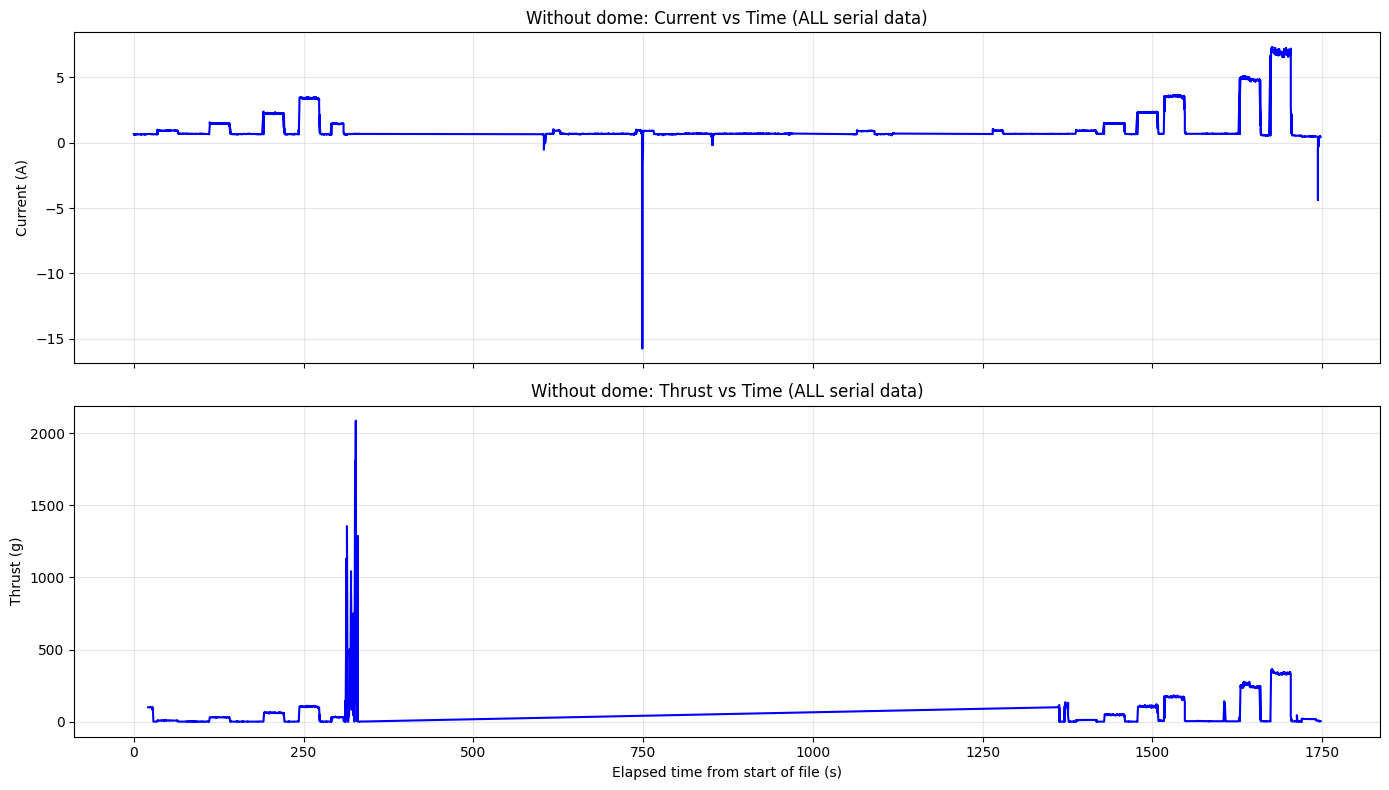

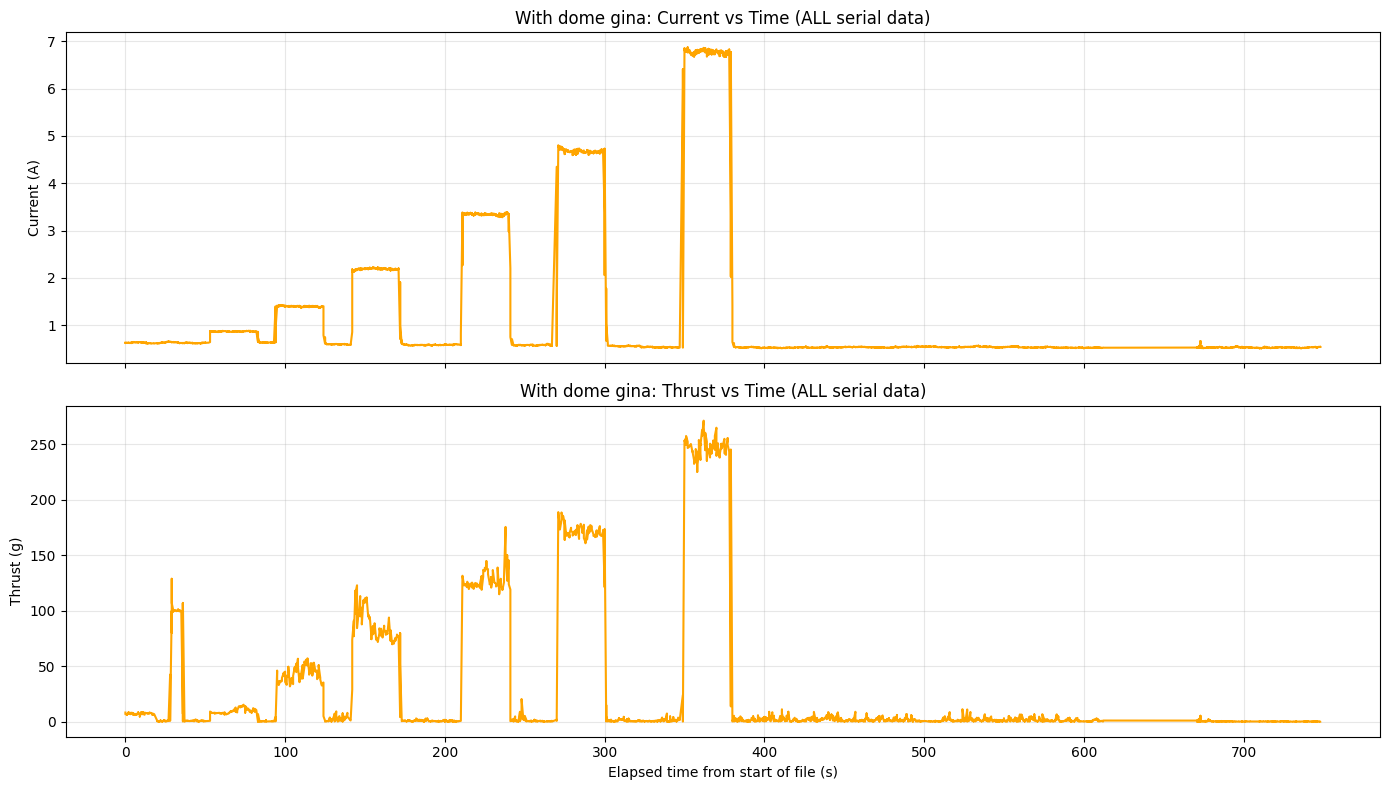

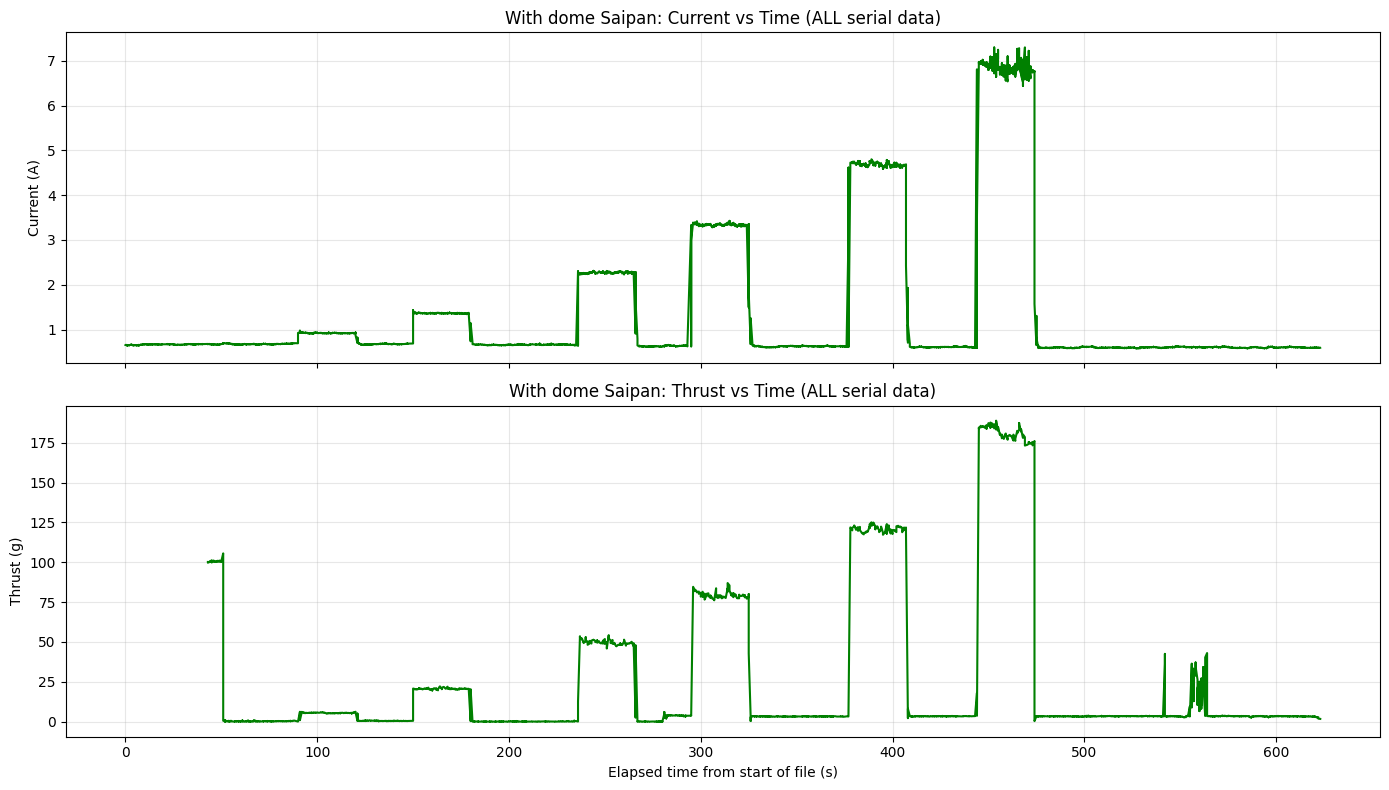

In [6]:
def plot_all_serial_timeseries(base_dir):
    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    folders = [p for p in Path(base_dir).iterdir() if p.is_dir()]
    folders = sorted(folders, key=lambda p: condition_order.index(p.name) if p.name in condition_order else 999)

    for folder in folders:
        condition = folder.name
        csv_path = folder / "plot_data.csv"

        if not csv_path.exists():
            print(f"{condition}: missing plot_data.csv")
            continue

        df = parse_plot_csv(csv_path)
        if df.empty:
            print(f"{condition}: no data")
            continue

        df["elapsed_s"] = (df["pc_time"] - df["pc_time"].iloc[0]).dt.total_seconds()

        color = condition_colors.get(condition, None)

        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        axes[0].plot(df["elapsed_s"], df["current_a"], color=color)
        axes[0].set_title(f"{condition}: Current vs Time (ALL serial data)")
        axes[0].set_ylabel("Current (A)")
        axes[0].grid(True, alpha=0.3)

        thrust_df = df[df[thrust_col].notna()].copy()
        axes[1].plot(thrust_df["elapsed_s"], thrust_df[thrust_col], color=color)
        axes[1].set_title(f"{condition}: Thrust vs Time (ALL serial data)")
        axes[1].set_xlabel("Elapsed time from start of file (s)")
        axes[1].set_ylabel("Thrust (g)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


plot_all_serial_timeseries(base_dir)


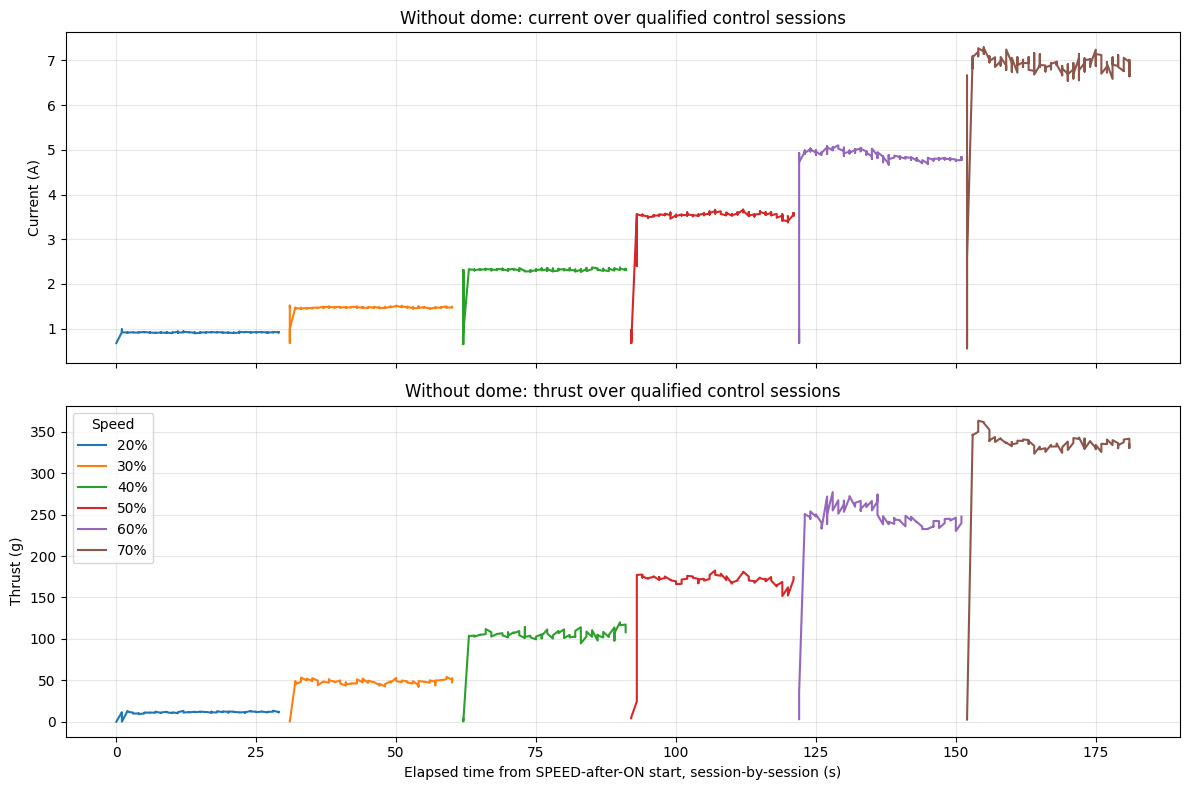

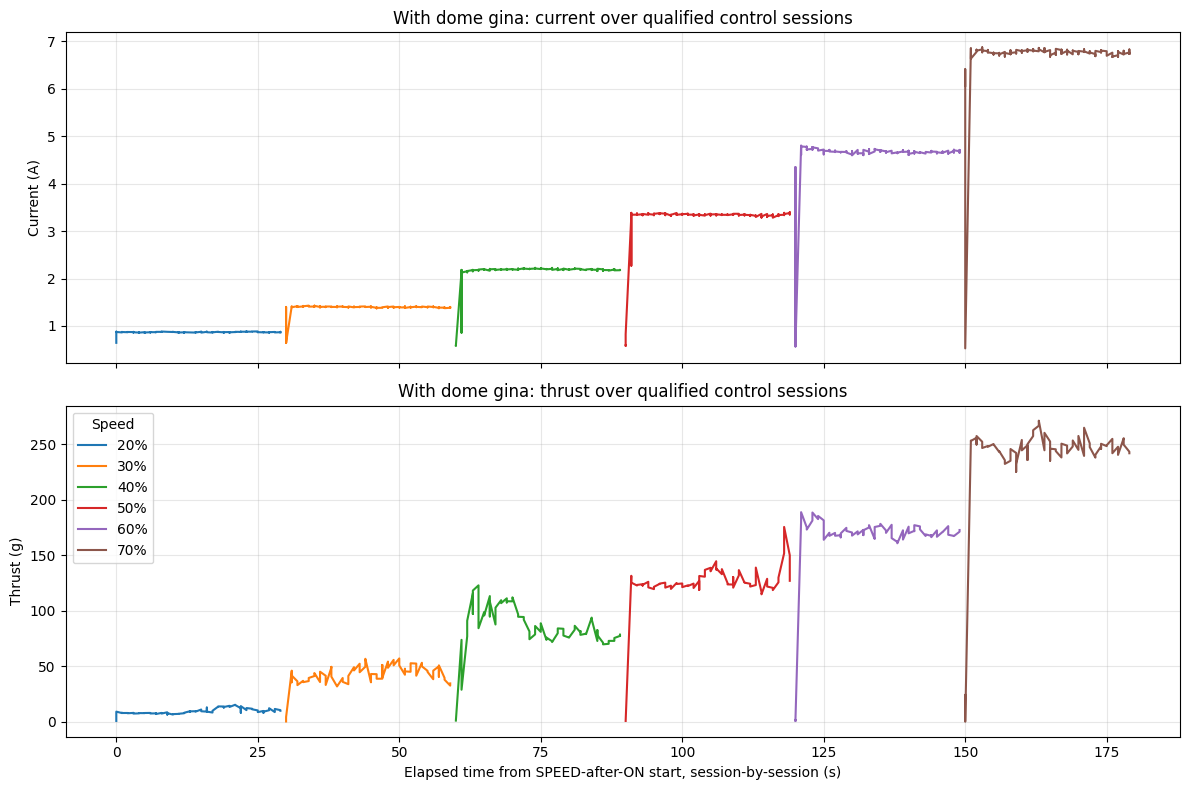

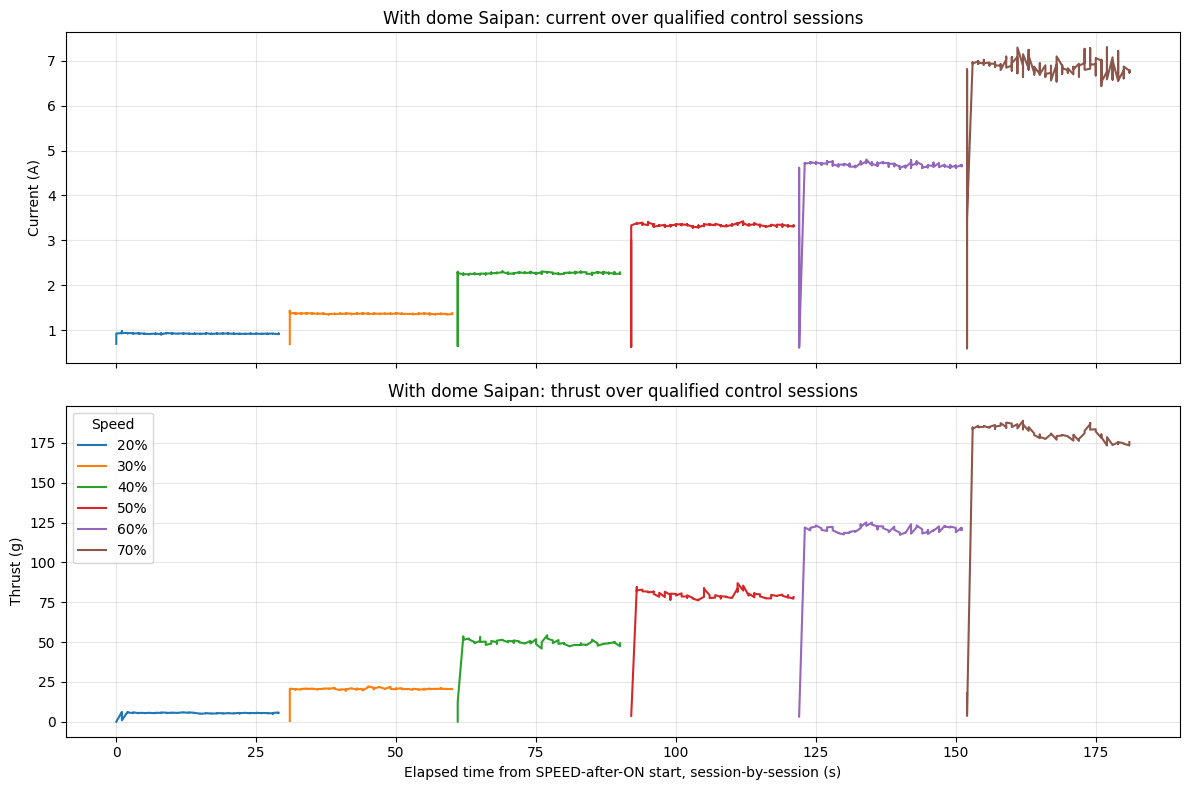

In [18]:
def plot_raw_timeseries(raw_interest, qualified_only=True, gap_s=1.0):
    thrust_col = "thrust_abs_g" if use_absolute_thrust else "thrust_g"

    for condition, df in raw_interest.items():
        if df.empty:
            continue

        work = df.copy()

        # Optional: keep only qualified sessions
        if qualified_only and "qualifies" in work.columns:
            work = work[work["qualifies"] == True].copy()

        if work.empty:
            continue

        # Build one continuous plotting axis:
        # each control session starts at 0 from its SPEED-after-ON start,
        # then gets shifted forward by the total length of previous sessions + gap
        session_blocks = []
        cursor_s = 0.0

        if "segment_start_ts" in work.columns:
            session_order = (
                work[["control_session_id", "segment_start_ts"]]
                .drop_duplicates()
                .sort_values(["segment_start_ts", "control_session_id"])
            )
            ordered_session_ids = session_order["control_session_id"].tolist()
        else:
            ordered_session_ids = work["control_session_id"].drop_duplicates().tolist()

        for session_id in ordered_session_ids:
            grp = work[work["control_session_id"] == session_id].copy()
            if grp.empty:
                continue

            grp = grp.sort_values("pc_time").copy()

            start_ts = grp["segment_start_ts"].iloc[0] if "segment_start_ts" in grp.columns else grp["pc_time"].iloc[0]
            grp["plot_elapsed_s"] = (grp["pc_time"] - start_ts).dt.total_seconds() + cursor_s

            session_blocks.append(grp)

            session_duration = (grp["pc_time"].max() - start_ts).total_seconds()
            cursor_s += max(session_duration, 0) + gap_s

        plot_df = pd.concat(session_blocks, ignore_index=True)
        plot_df = plot_df.sort_values("plot_elapsed_s")

        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # Keep one consistent color per speed using matplotlib's default cycle
        speed_values = sorted(plot_df["speed_pct"].dropna().unique())
        default_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
        speed_to_color = {
            speed: default_colors[i % len(default_colors)]
            for i, speed in enumerate(speed_values)
        }

        shown_labels = set()

        # Plot each session separately so lines do not connect across repeated speeds
        for session_id in ordered_session_ids:
            grp = plot_df[plot_df["control_session_id"] == session_id].copy()
            if grp.empty:
                continue

            speed = grp["speed_pct"].iloc[0] if "speed_pct" in grp.columns else np.nan
            color = speed_to_color.get(speed, None)

            label = None
            if pd.notna(speed) and speed not in shown_labels:
                label = f"{int(speed)}%"
                shown_labels.add(speed)

            axes[0].plot(
                grp["plot_elapsed_s"],
                grp["current_a"],
                label=label,
                color=color
            )

            thrust_part = grp[grp[thrust_col].notna()]
            axes[1].plot(
                thrust_part["plot_elapsed_s"],
                thrust_part[thrust_col],
                label=label,
                color=color
            )

        title_suffix = "qualified control sessions" if qualified_only else "control sessions"

        axes[0].set_title(f"{condition}: current over {title_suffix}")
        axes[0].set_ylabel("Current (A)")
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title(f"{condition}: thrust over {title_suffix}")
        axes[1].set_xlabel("Elapsed time from SPEED-after-ON start, session-by-session (s)")
        axes[1].set_ylabel("Thrust (g)")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(title="Speed")

        plt.tight_layout()
        plt.show()


plot_raw_timeseries(raw_interest, qualified_only=True, gap_s=1.0)

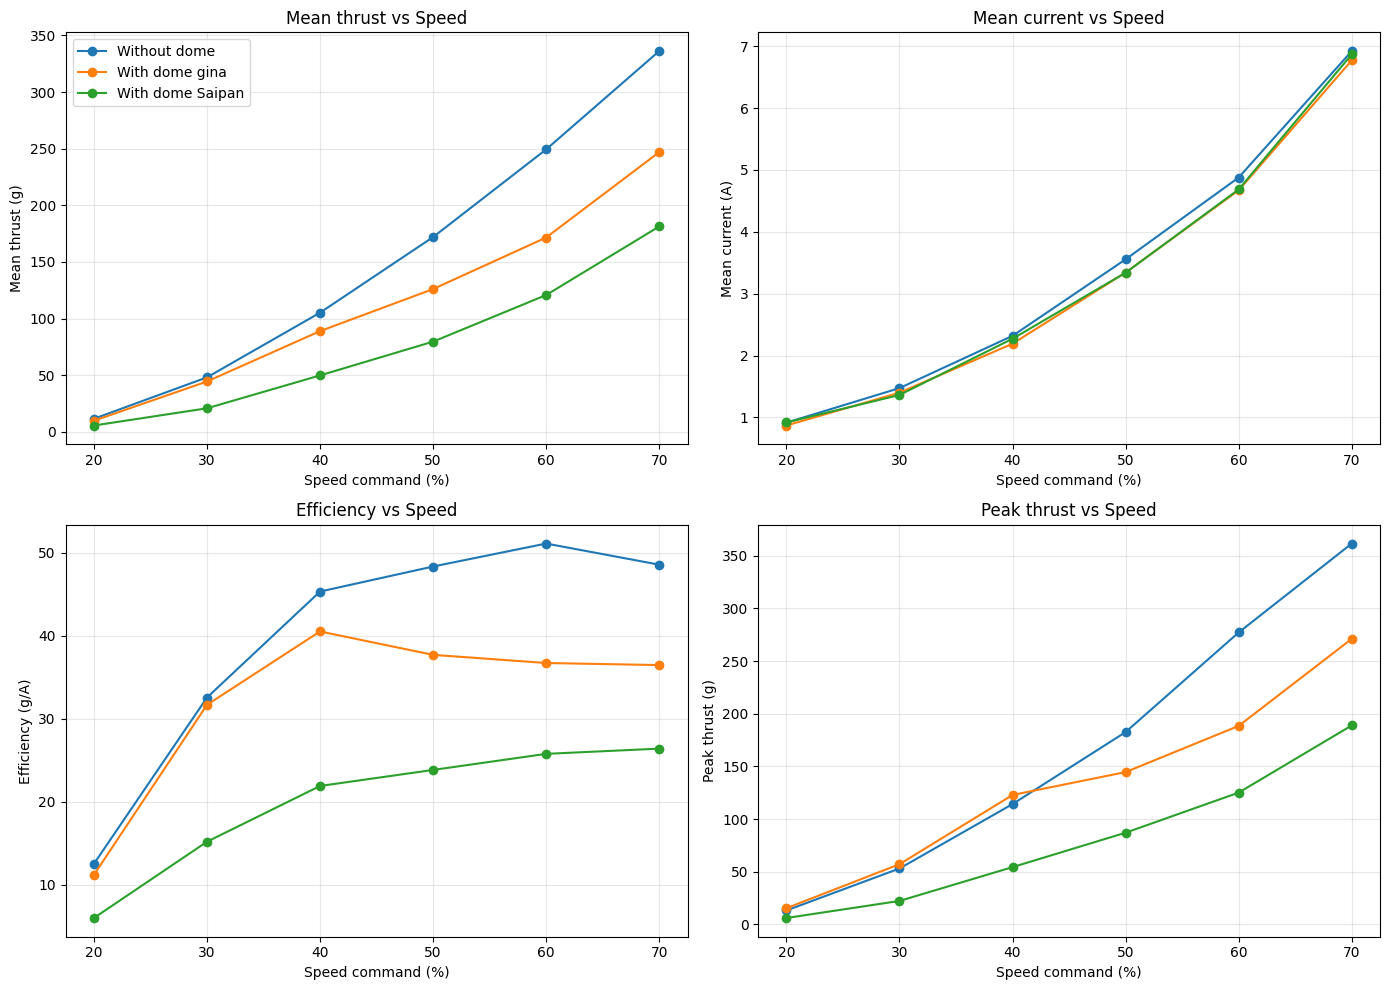

In [15]:
def ordered_conditions(df, column="condition"):
    if df.empty or column not in df.columns:
        return []
    existing = list(df[column].dropna().unique())
    ordered = [c for c in condition_order if c in existing]
    ordered += [c for c in existing if c not in ordered]
    return ordered


def plot_compare_lines(per_speed_df):
    if per_speed_df.empty:
        print("No per-speed data available.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    specs = [
        ("thrust_mean_g_weighted", "Mean thrust (g)", "Mean thrust vs Speed"),
        ("current_mean_A_weighted", "Mean current (A)", "Mean current vs Speed"),
        ("efficiency_g_per_A_weighted", "Efficiency (g/A)", "Efficiency vs Speed"),
        ("thrust_peak_g_max", "Peak thrust (g)", "Peak thrust vs Speed"),
    ]

    ordered = ordered_conditions(per_speed_df)

    for ax, (col, ylabel, title) in zip(axes, specs):
        for condition in ordered:
            grp = per_speed_df[per_speed_df["condition"] == condition].sort_values("speed_pct")
            if len(grp):
                ax.plot(grp["speed_pct"], grp[col], marker="o", label=condition)
        ax.set_xlabel("Speed command (%)")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    plt.tight_layout()
    plt.show()


plot_compare_lines(per_speed_df)


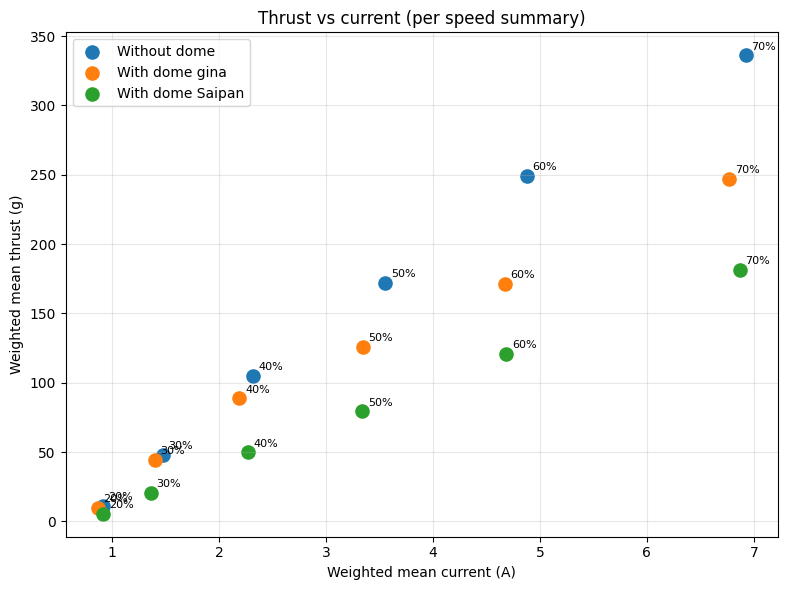

In [16]:
def plot_scatter_thrust_vs_current(per_speed_df):
    if per_speed_df.empty:
        print("No per-speed data available.")
        return

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ordered = ordered_conditions(per_speed_df)

    for condition in ordered:
        grp = per_speed_df[per_speed_df["condition"] == condition].sort_values("speed_pct")
        if grp.empty:
            continue

        ax.scatter(grp["current_mean_A_weighted"], grp["thrust_mean_g_weighted"], s=90, label=condition)

        for _, row in grp.iterrows():
            ax.annotate(
                f'{int(row["speed_pct"])}%',
                (row["current_mean_A_weighted"], row["thrust_mean_g_weighted"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=8,
            )

    ax.set_title("Thrust vs current per speed")
    ax.set_xlabel("Weighted mean current (A)")
    ax.set_ylabel("Weighted mean thrust (g)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_scatter_thrust_vs_current(per_speed_df)
